
# FRED Series Data Analysis


In [38]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
pd.options.display.max_columns = 120


In [39]:

EVENT_STYLE = {
    "gfc": {"color": "#d62728", "alpha": 0.15, "label": "2007-09: Subprime, Bear/Lehman, TARP, QE1"},
    "euro": {"color": "#9467bd", "alpha": 0.12, "label": "2010-12: Flash Crash, US downgrade, Euro debt crisis"},
    "taper": {"color": "#8c564b", "alpha": 0.12, "label": "2013-15: Taper tantrum & oil collapse"},
    "china_brexit": {"color": "#e377c2", "alpha": 0.12, "label": "2015-16: China deval & Brexit shock"},
    "trade": {"color": "#1f77b4", "alpha": 0.12, "label": "2018-19: Trade war, Fed hikes, repo stress"},
    "covid": {"color": "#2ca02c", "alpha": 0.12, "label": "2020: COVID crash, oil below zero, stimulus"},
    "inflation": {"color": "#ff7f0e", "alpha": 0.12, "label": "2022: Inflation spike & Russia-Ukraine"},
    "banks": {"color": "#17becf", "alpha": 0.12, "label": "2023: Bank failures & AI rebound"},
}

EVENT_PERIODS = [
    {"start": "2007-01-01", "end": "2009-06-30", "style": "gfc"},
    {"start": "2010-01-01", "end": "2012-12-31", "style": "euro"},
    {"start": "2013-05-01", "end": "2015-12-31", "style": "taper"},
    {"start": "2015-06-01", "end": "2016-12-31", "style": "china_brexit"},
    {"start": "2018-01-01", "end": "2019-12-31", "style": "trade"},
    {"start": "2020-02-01", "end": "2020-12-31", "style": "covid"},
    {"start": "2022-01-01", "end": "2022-12-31", "style": "inflation"},
    {"start": "2023-03-01", "end": "2023-12-31", "style": "banks"},
]

EVENT_LINES = [
    {"date": "2008-09-15", "label": "Lehman collapse"},
    {"date": "2011-08-05", "label": "US downgrade"},
    {"date": "2016-06-23", "label": "Brexit vote"},
    {"date": "2020-03-23", "label": "COVID bear low"},
    {"date": "2022-02-24", "label": "Russia invades Ukraine"},
    {"date": "2023-03-10", "label": "SVB failure"},
]

def add_event_overlays(ax, include_handles=True):
    """Overlay crisis periods and notable market events on time-series axes."""
    handles = []
    used_styles = set()
    ymin, ymax = ax.get_ylim()
    for event in EVENT_PERIODS:
        start = pd.Timestamp(event["start"])
        end = pd.Timestamp(event["end"])
        style = EVENT_STYLE[event["style"]]
        ax.axvspan(start, end, color=style["color"], alpha=style["alpha"], lw=0)
        if include_handles and event["style"] not in used_styles:
            handles.append(Patch(facecolor=style["color"], alpha=style["alpha"], label=style["label"]))
            used_styles.add(event["style"])
    for marker in EVENT_LINES:
        ts = pd.Timestamp(marker["date"])
        ax.axvline(ts, color="black", linestyle="--", linewidth=0.8)
        ax.annotate(
            marker["label"],
            xy=(ts, ymax),
            xytext=(0, -15),
            textcoords="offset points",
            rotation=90,
            va="top",
            ha="right",
            fontsize=8,
            color="black",
            annotation_clip=False,
        )
    ax.set_ylim(ymin, ymax)
    if include_handles:
        return handles
    return []

def add_legend_with_events(ax, event_handles, title="Series / events"):
    handles, labels = ax.get_legend_handles_labels()
    if event_handles:
        handles = handles + event_handles
        labels = labels + [h.get_label() for h in event_handles]
    if handles:
        # Place legend outside plot area with multiple columns to prevent overlap
        ax.legend(
            handles, 
            labels, 
            title=title,
            bbox_to_anchor=(1.05, 1),
            loc='upper left',
            ncol=1,
            fontsize=9,
            framealpha=0.95
        )


In [40]:

DATA_PATH = Path("..") / "data_collectors" / "fred_series_data.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = df.sort_values("date").set_index("date")
df = df.apply(pd.to_numeric, errors="coerce")

print(
    f"Loaded {df.shape[0]:,} monthly observations with {df.shape[1]} indicators "
    f"spanning {df.index.min().date()} to {df.index.max().date()}."
)


Loaded 204 monthly observations with 103 indicators spanning 2007-01-31 to 2023-12-31.


In [41]:
df.head()

,RPI,W875RX1,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,IPNCONGD,IPBUSEQ,IPMAT,IPDMAT,IPNMAT,IPMANSICS,IPB51222S,IPFUELS,CUMFNS,CLF16OV,CE16OV,UNRATE,UEMPMEAN,PAYEMS,USGOOD,USCONS,MANEMP,DMANEMP,NDMANEMP,SRVPRD,USTPU,USTRADE,USFIRE,USGOVT,CES0600000007,AWOTMAN,AWHMAN,CES0600000008,CES2000000008,CES3000000008,HOUST,HOUSTNE,HOUSTMW,HOUSTS,HOUSTW,PERMIT,PERMITNE,PERMITMW,PERMITS,PERMITW,DPCERA3M086SBEA,CMRMTSPL,RSAFS,ACOGNO,ANDENO,AMDMUO,BUSINV,ISRATIO,UMCSENT,M1SL,M2SL,M2REAL,AMBSL,TOTRESNS,NONBORRES,BUSLOANS,REALLN,NONREVSL,MZMSL,DTCOLNVHFNM,DTCTHFNM,INVEST,FEDFUNDS,CPF3M,TB3MS,TB6MS,GS1,GS5,GS10,AAA,BAA,EXSZUS,EXJPUS,EXUSUK,EXCAUS,PPIFGS,PPIFCG,PPIITM,PPICRM,MCOILWTICO,PPICMM,CPIAUCSL,CPIAPPSL,CPITRNSL,CPIMEDSL,CUSR0000SAC,CUUR0000SAD,CUSR0000SAS,CPIULFSL,CUUR0000SA0L2,CUSR0000SA0L5,PCEPI,DDURRG3M086SBEA,DNDGRG3M086SBEA,DSERRG3M086SBEA,SP500
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2007-01-31,13651.743,11666.7,99.7546,108.4999,106.6165,110.5145,101.6873,112.6592,95.8220,90.6949,92.9120,112.1414,105.7628,96.8734,87.4541,78.7154,153144.0,146028.0,4.6,16.3,137472.0,22434.0,7725.0,14004.0,8886.0,5118.0,115038.0,26381.0,15411.5,8388.0,22095.0,40.4,4.1,41.0,18.37,20.56,17.01,1409.0,178.0,191.0,712.0,328.0,1626.0,184.0,267.0,785.0,390.0,84.127,1226965.0,355792.0,163494.0,72901.0,808745.0,1401566.0,1.30,96.9,1371.7,7118.3,3499.0,843.499,44.6,44.4,1192.2900,3394.4599,1530316.12,7260.7,262033.15,830990.10,2003.6584,5.25,5.24,4.98,4.95,5.06,4.75,4.76,5.40,6.34,1.2431,120.4471,1.9587,1.1763,160.9,166.1,164.1,184.9,54.51,251.5,203.437,119.860,177.090,343.579,163.335,113.263,243.214,204.297,191.328,196.344,85.316,121.655,86.816,80.236,NaN
2007-02-28,13711.191,11713.7,100.7166,109.4825,107.7129,111.7575,102.9188,113.8961,96.5591,91.6361,93.6388,112.6619,106.1218,109.4908,86.2906,78.7814,152983.0,146057.0,4.5,16.7,137558.0,22329.0,7626.0,13993.0,8886.0,5107.0,115229.0,26426.0,15440.3,8391.0,22131.0,40.2,4.1,40.9,18.39,20.59,17.05,1480.0,137.0,163.0,796.0,384.0,1598.0,144.0,222.0,815.0,417.0,84.106,1234327.0,356545.0,167361.0,74961.0,816748.0,1408178.0,1.29,91.3,1363.0,7134.3,3493.3,847.260,42.6,42.6,1204.8529,3422.3617,1536694.12,7279.8,259521.70,828199.65,2010.4455,5.26,5.23,5.03,4.96,5.05,4.71,4.72,5.39,6.28,1.2393,120.5047,1.9589,1.1710,162.7,168.3,165.3,201.6,59.28,253.2,204.226,120.237,177.727,345.350,164.066,113.210,244.091,204.992,192.272,197.089,85.581,121.647,87.274,80.475,NaN
2007-03-31,13762.811,11765.5,100.8952,109.5398,107.5670,110.8851,103.4197,112.5525,98.3138,91.9460,94.6999,114.1978,106.9888,100.3407,87.9340,79.2181,153051.0,146320.0,4.4,17.8,137782.0,22384.0,7706.0,13964.0,8865.0,5099.0,115398.0,26492.0,15498.8,8381.0,22149.0,40.6,4.3,41.3,18.47,20.68,17.10,1495.0,131.0,234.0,752.0,378.0,1596.0,164.0,244.0,777.0,411.0,84.200,1235875.0,359415.0,170197.0,83612.0,829553.0,1410230.0,1.28,88.4,1366.5,7168.2,3491.8,848.177,40.7,40.6,1215.6537,3363.4269,1545969.60,7336.0,262576.94,831085.90,2018.0856,5.26,5.22,4.94,4.89,4.92,4.48,4.56,5.30,6.27,1.2178,117.2600,1.9474,1.1682,164.1,170.3,166.7,203.6,60.44,264.7,205.288,119.797,181.041,345.899,165.554,113.163,244.743,206.114,194.482,198.161,85.894,121.325,88.214,80.671,NaN
2007-04-30,13784.697,11801.5,101.5723,110.2120,108.3168,111.4533,105.2181,112.6872,99.2687,92.6300,95.6740,114.6540,107.6504,102.3173,86.3047,79.4993,152435.0,145586.0,4.5,16.9,137845.0,22345.0,7686.0,13939.0,8854.0,5085.0,115500.0,26491.0,15477.4,8362.0,22175.0,40.5,4.2,41.3,18.56,20.78,17.20,1490.0,166.0,206.0,732.0,386.0,1470.0,159.0,222.0,727.0,362.0,84.281,1233744.0,358562.0,171494.0,83261.0,844913.0,1419110.0,1.28,87.1,1378.0,7240.7,3516.5,848.954,42.5,42.4,1226.6366,3391.2159,1552343.26,7430.2,262969.09,837718.92,2025.9263,5.25,5.23,4.87,4.86,4.93,4.59,4.69,5.47,6.39,1.2124,118.9324,1.9879,1.1350,165.3,171.9,168.3,204.0,63.98,289.7,205.904,119.331,182.489,347.320,166.198,112.989,245.315,206.747,196.062,198.742,86.096,121.035,88.629,80.867,NaN
200

In [42]:

key_stats_cols = [
    "RPI",
    "INDPRO",
    "UNRATE",
    "PAYEMS",
    "SP500",
    "FEDFUNDS",
    "TB3MS",
    "CPIAUCSL",
    "PCEPI",
    "M2SL",
]
summary_view = df[key_stats_cols].describe().T[["mean", "std", "min", "max"]].round(2)
summary_view


,mean,std,min,max
RPI,16171.65,2122.87,13460.83,22918.42
INDPRO,98.62,4.69,84.67,104.10
UNRATE,6.04,2.24,3.40,14.80
PAYEMS,141622.42,7786.45,129705.00,156930.00
SP500,3246.09,839.61,1904.42,4685.05
FEDFUNDS,1.20,1.64,0.05,5.33
TB3MS,1.12,1.58,0.01,5.34
CPIAUCSL,243.26,26.41,203.44,308.74
PCEPI,99.23,9.19,85.32,121.66
M2SL,13042.58,4553.86,7118.30,21749.90


In [43]:

missing = (df.isna().mean() * 100).sort_values(ascending=False)
missing.head(10).to_frame(name="percent_missing")


,percent_missing
SP500,52.450980
PPIFGS,47.058824
PPIFCG,47.058824
PPIITM,47.058824
PPICRM,47.058824
AMBSL,24.019608
MZMSL,17.156863
CPF3M,0.490196
M2REAL,0.000000
TOTRESNS,0.000000



## Industrial Production Momentum
Normalizing the industrial production-related indicators highlights how market events forced synchronized drops before the subsequent recoveries.


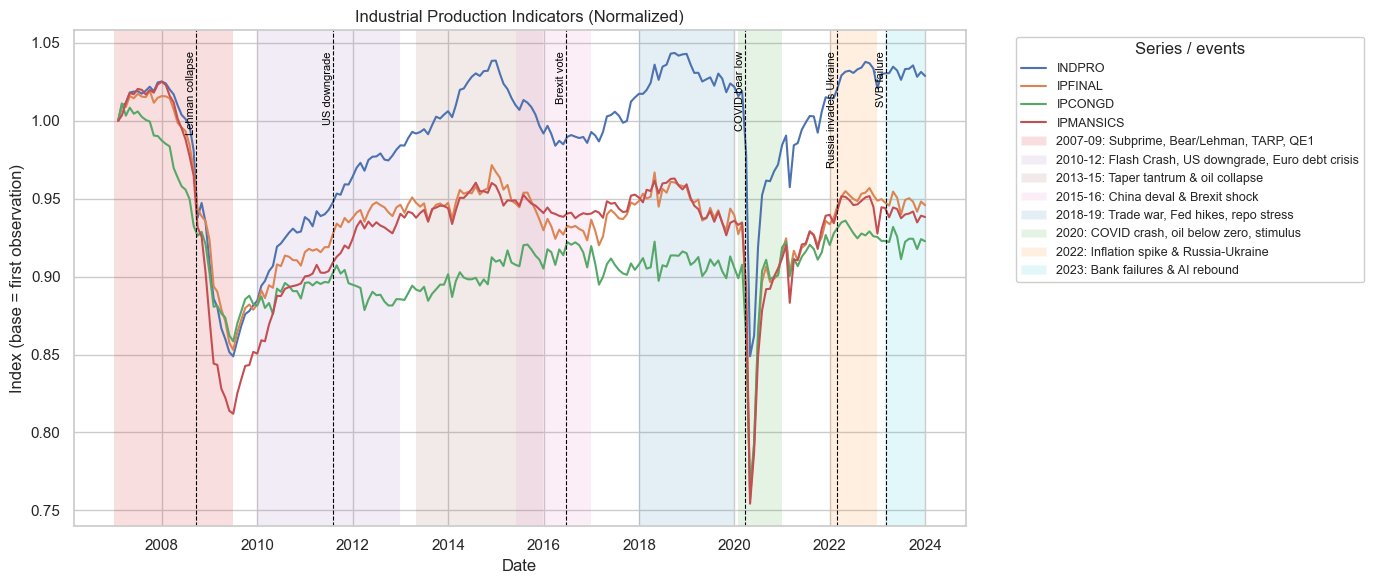

In [44]:

macro_cols = ["INDPRO", "IPFINAL", "IPCONGD", "IPMANSICS"]
macro = df[macro_cols].dropna()
normalized_macro = macro / macro.iloc[0]
fig, ax = plt.subplots(figsize=(14, 6))
for col in normalized_macro.columns:
    ax.plot(normalized_macro.index, normalized_macro[col], label=col)
ax.set_title("Industrial Production Indicators (Normalized)")
ax.set_xlabel("Date")
ax.set_ylabel("Index (base = first observation)")
event_handles = add_event_overlays(ax)
add_legend_with_events(ax, event_handles, title="Series / events")
plt.tight_layout()
plt.show()



## Labor Market Trends
Payroll employment and the unemployment rate show how hiring activity responds to broader economic cycles—the shaded overlays capture how layoffs spiked during the global financial crisis, Euro crisis jitters, COVID lockdowns, and the 2022 inflation shock.


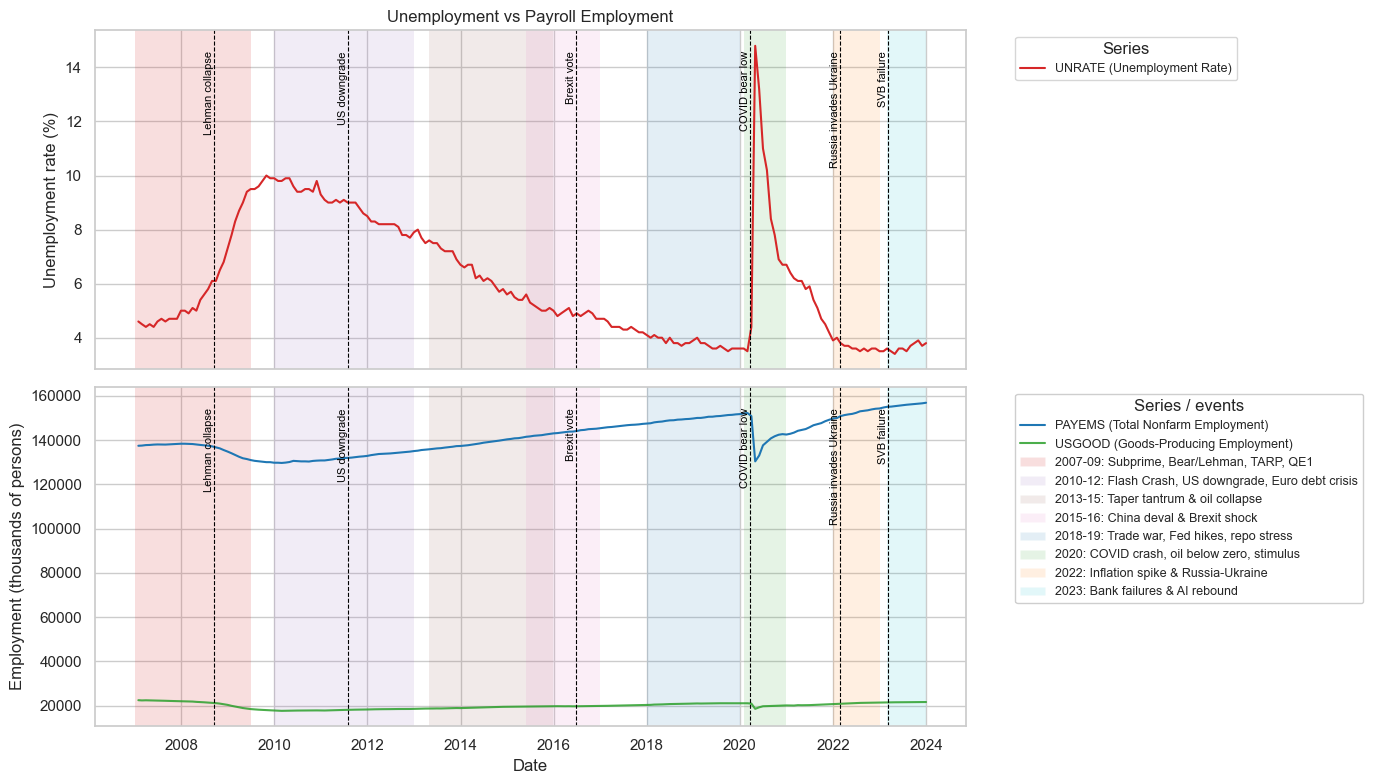

In [45]:

labor_cols = ["UNRATE", "PAYEMS", "USGOOD"]
labor = df[labor_cols].dropna()
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(labor.index, labor["UNRATE"], color="tab:red", label="UNRATE (Unemployment Rate)")
axes[0].set_title("Unemployment vs Payroll Employment")
axes[0].set_ylabel("Unemployment rate (%)")
axes[0].legend(title="Series", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

axes[1].plot(labor.index, labor["PAYEMS"], color="tab:blue", label="PAYEMS (Total Nonfarm Employment)")
axes[1].plot(
    labor.index,
    labor["USGOOD"],
    color="tab:green",
    label="USGOOD (Goods-Producing Employment)",
    alpha=0.85,
)
axes[1].set_ylabel("Employment (thousands of persons)")
axes[1].set_xlabel("Date")
axes[1].legend(title="Series")

add_event_overlays(axes[0], include_handles=False)
labor_event_handles = add_event_overlays(axes[1])
add_legend_with_events(axes[1], labor_event_handles, title="Series / events")
plt.tight_layout()
plt.show()



## Housing Starts and Permits
Housing starts and building permits (3-month averages) capture turning points in residential construction and make the 2007 housing bust and 2020 lockdown halt immediately visible.


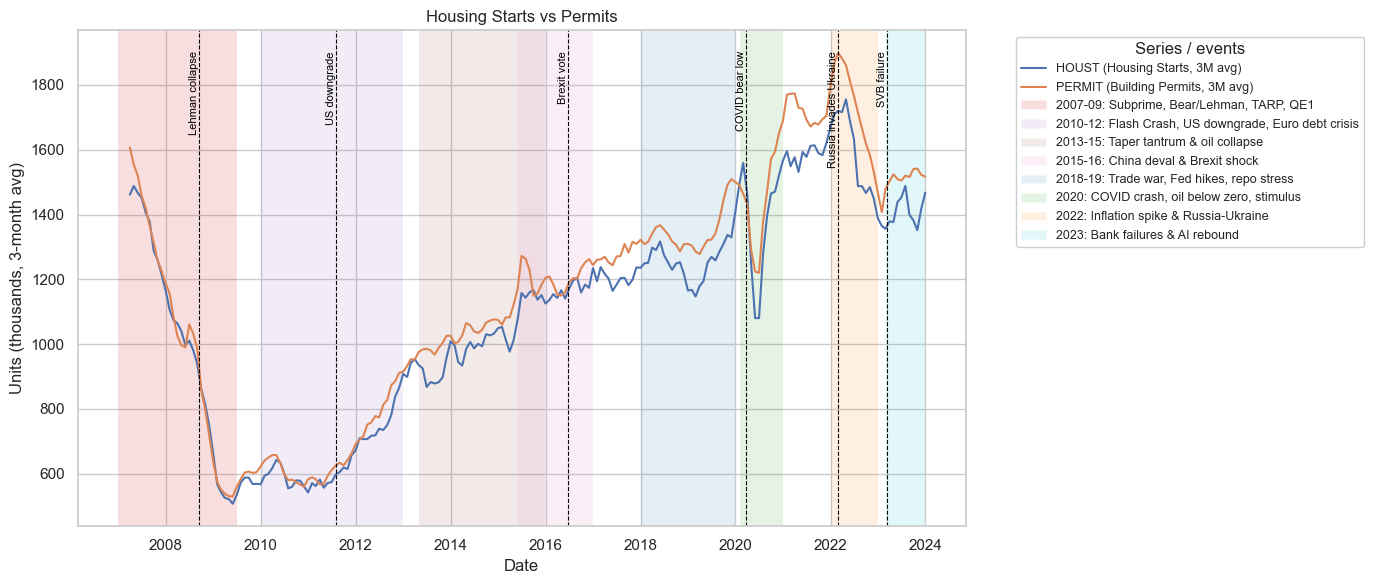

In [46]:

housing_cols = ["HOUST", "PERMIT"]
housing = df[housing_cols].dropna().rolling(window=3).mean()
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(housing.index, housing["HOUST"], label="HOUST (Housing Starts, 3M avg)")
ax.plot(housing.index, housing["PERMIT"], label="PERMIT (Building Permits, 3M avg)")
ax.set_title("Housing Starts vs Permits")
ax.set_xlabel("Date")
ax.set_ylabel("Units (thousands, 3-month avg)")
event_handles = add_event_overlays(ax)
add_legend_with_events(ax, event_handles, title="Series / events")
plt.tight_layout()
plt.show()



## Sentiment, Equity Prices, and Real Income
Comparing consumer sentiment, the S&P 500, and real personal income on a normalized scale—alongside policy/event overlays. Reveals when financial markets sell off ahead of income weakness (2008, 2020) and when policy support revives risk appetite (2012, 2023 AI rebound).


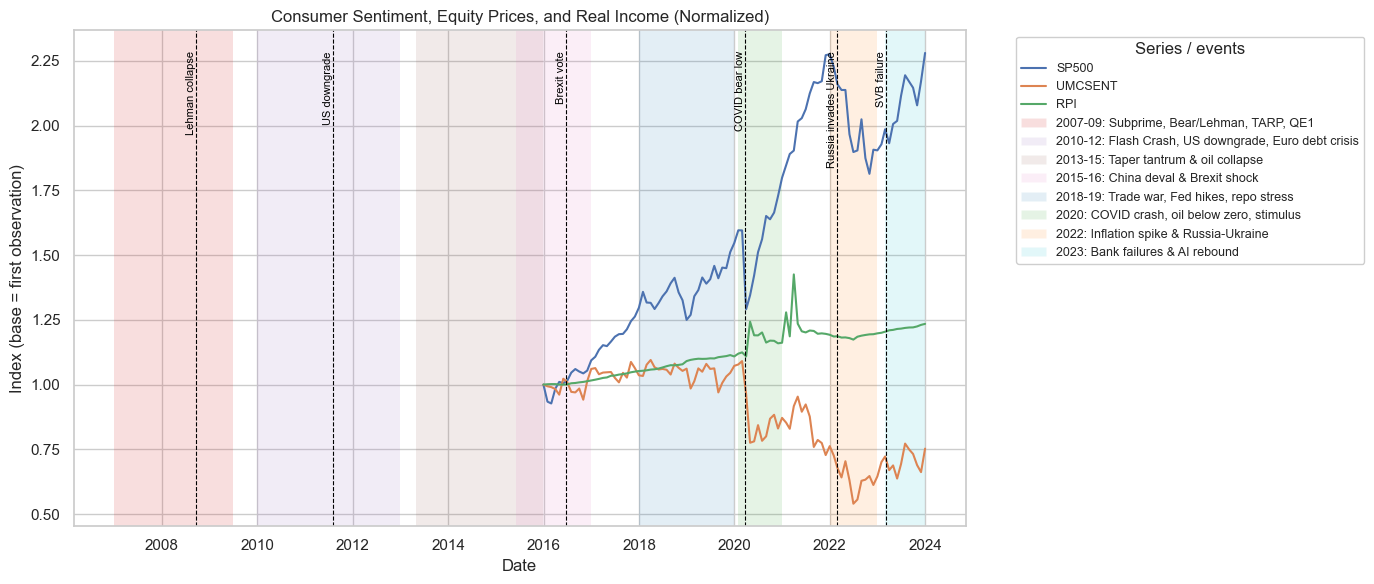

In [47]:

sentiment_cols = ["SP500", "UMCSENT", "RPI"]
sentiment = df[sentiment_cols].dropna()
normalized_sentiment = sentiment / sentiment.iloc[0]
fig, ax = plt.subplots(figsize=(14, 6))
for col in normalized_sentiment.columns:
    ax.plot(normalized_sentiment.index, normalized_sentiment[col], label=col)
ax.set_title("Consumer Sentiment, Equity Prices, and Real Income (Normalized)")
ax.set_xlabel("Date")
ax.set_ylabel("Index (base = first observation)")
event_handles = add_event_overlays(ax)
add_legend_with_events(ax, event_handles, title="Series / events")
plt.tight_layout()
plt.show()



## Inflation and Money Supply Momentum
Year-over-year percent changes contextualize the surge and cooling in consumer prices, producer prices, and broad money supply, emphasizing the 2021-22 inflation shock triggered by reopening demand and the Ukraine invasion.


/var/folders/bz/59qh8315079708xct3crpck00000gn/T/ipykernel_46435/2142477077.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  inflation_trends = df[price_cols].pct_change(periods=12) * 100


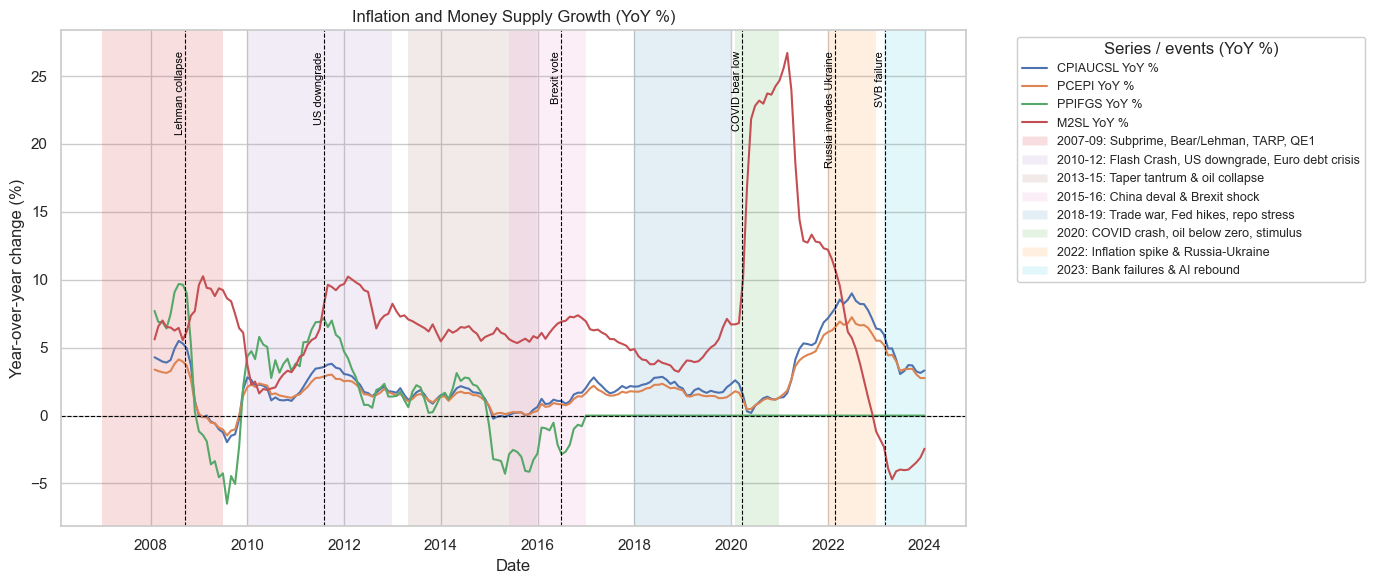

In [48]:

price_cols = ["CPIAUCSL", "PCEPI", "PPIFGS", "M2SL"]
inflation_trends = df[price_cols].pct_change(periods=12) * 100
inflation_trends = inflation_trends.dropna()
fig, ax = plt.subplots(figsize=(14, 6))
for col in inflation_trends.columns:
    ax.plot(inflation_trends.index, inflation_trends[col], label=f"{col} YoY %")
ax.set_title("Inflation and Money Supply Growth (YoY %)")
ax.set_xlabel("Date")
ax.set_ylabel("Year-over-year change (%)")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
event_handles = add_event_overlays(ax)
add_legend_with_events(ax, event_handles, title="Series / events (YoY %)")
plt.tight_layout()
plt.show()



## Credit Spreads and Curve Shape
Credit spreads and the slope between long rates and the policy rate often react fastest to macro shocks, making them critical for stress-testing loss assumptions.


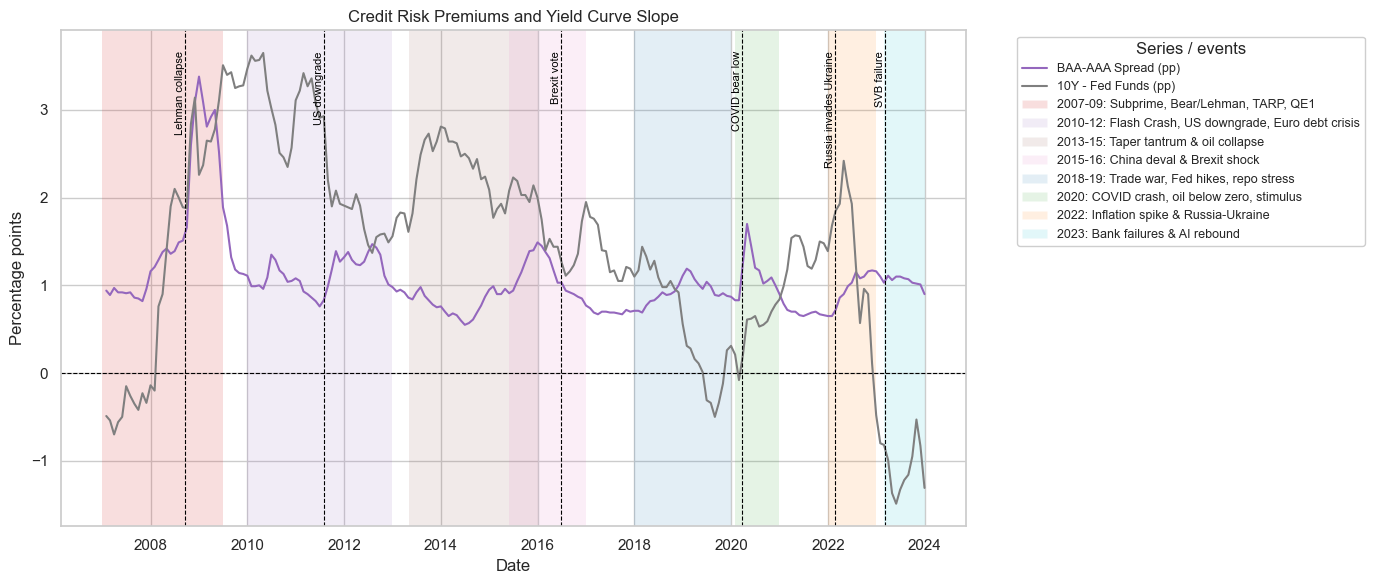

In [49]:

spread = pd.DataFrame({
    "BAA-AAA Spread (pp)": df["BAA"] - df["AAA"],
    "10Y - Fed Funds (pp)": df["GS10"] - df["FEDFUNDS"],
}).dropna()
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(spread.index, spread["BAA-AAA Spread (pp)"], label="BAA-AAA Spread (pp)", color="tab:purple")
ax.plot(spread.index, spread["10Y - Fed Funds (pp)"], label="10Y - Fed Funds (pp)", color="tab:gray")
ax.set_title("Credit Risk Premiums and Yield Curve Slope")
ax.set_xlabel("Date")
ax.set_ylabel("Percentage points")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
event_handles = add_event_overlays(ax)
add_legend_with_events(ax, event_handles, title="Series / events")
plt.tight_layout()
plt.show()



The BAA-AAA spread flares during every shaded stress episode, while the 10Y-Fed Funds term spread inverts before recessions (2007, 2019, 2022), reinforcing why credit conditions are a leading indicator for loss modeling.



## Interest Rates and Credit Spreads
Correlations across the yield curve and corporate spreads illustrate how tightening cycles ripple through funding costs.


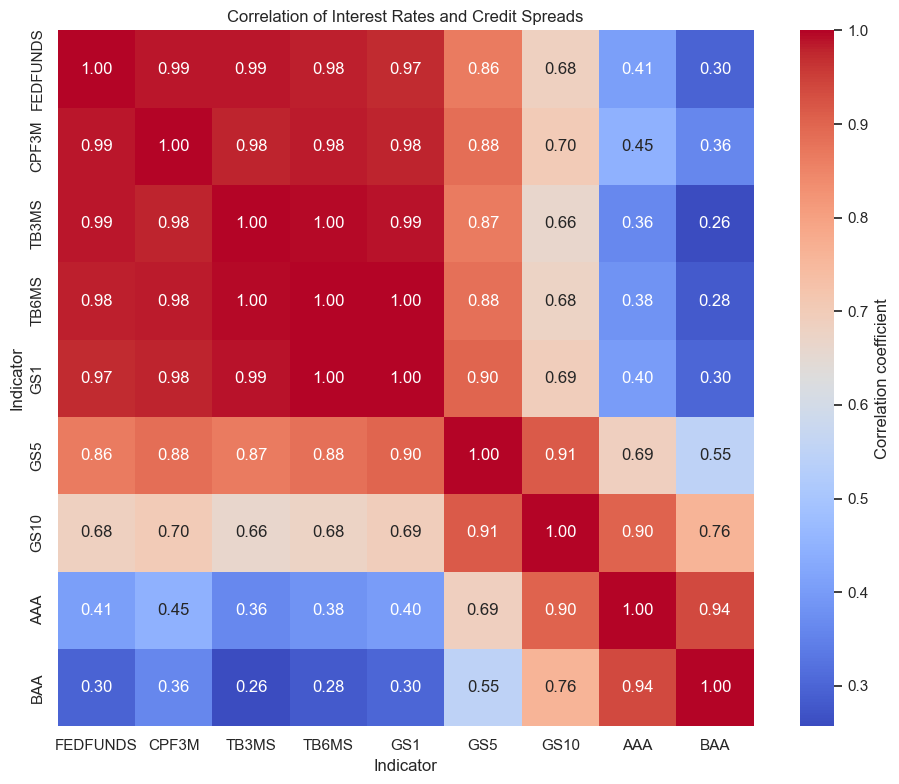

In [50]:

rate_cols = ["FEDFUNDS", "CPF3M", "TB3MS", "TB6MS", "GS1", "GS5", "GS10", "AAA", "BAA"]
rate_data = df[rate_cols].dropna()
corr = rate_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"label": "Correlation coefficient"},
)
plt.title("Correlation of Interest Rates and Credit Spreads")
plt.xlabel("Indicator")
plt.ylabel("Indicator")
plt.tight_layout()
plt.show()



### Quick Takeaways
- Shaded overlays tie each industrial production downswing to explicit shocks (housing bust, Euro crisis, COVID, inflation), clarifying when macro models should expect regime shifts.
- Labor charts show unemployment spikes and payroll drawdowns lining up with those episodes, while goods employment lags broader payrolls after each shock.
- Housing starts and permits confirm that construction retrenches before most downturns and reaccelerates once policy support (QE, stimulus) gains traction.
- Sentiment/SP500/income normalization shows how markets front-run recoveries (2012, 2023) and deteriorate sharply ahead of income weakness (2008, 2020).
- Credit spread and yield-curve analysis illustrates how funding stress and curve inversions anticipate recessions, complementing the interest-rate correlation heat map.
